In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("Final_Healthcare_Obesity_Dataset.csv")
df.isnull().sum()


Age                                0
Gender                             0
Weight                             0
Height                             0
FAVC                               0
CH2O                              35
FAF                               35
TUE                               35
family_history_with_overweight     0
NObeyesdad                         0
dtype: int64

In [2]:
df['CH2O'] = df['CH2O'].fillna(df['CH2O'].mean())
df['FAF'] = df['FAF'].fillna(df['FAF'].mean())
df['TUE'] = df['TUE'].fillna(df['TUE'].mean())

In [3]:
df.isnull().sum()

Age                               0
Gender                            0
Weight                            0
Height                            0
FAVC                              0
CH2O                              0
FAF                               0
TUE                               0
family_history_with_overweight    0
NObeyesdad                        0
dtype: int64

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             700 non-null    float64
 1   Gender                          700 non-null    object 
 2   Weight                          700 non-null    float64
 3   Height                          700 non-null    float64
 4   FAVC                            700 non-null    object 
 5   CH2O                            700 non-null    float64
 6   FAF                             700 non-null    float64
 7   TUE                             700 non-null    float64
 8   family_history_with_overweight  700 non-null    object 
 9   NObeyesdad                      700 non-null    object 
dtypes: float64(6), object(4)
memory usage: 43.8+ KB


In [5]:
df.drop_duplicates(inplace=True)
print(df.shape)
df.to_csv("Cleaned_Healthcare_Dataset.csv", index=False)
print("Cleaned dataset saved successfully")

(697, 10)
Cleaned dataset saved successfully


In [6]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_III       115
Obesity_Type_I         114
Normal_Weight          103
Obesity_Type_II         95
Overweight_Level_I      91
Insufficient_Weight     90
Overweight_Level_II     89
Name: count, dtype: int64

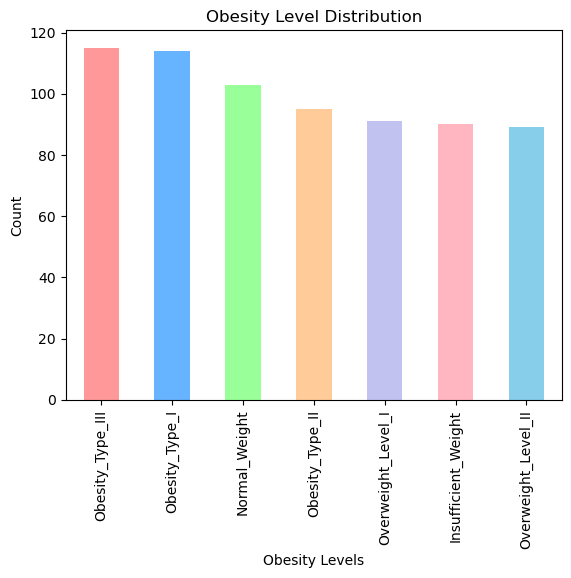

In [7]:
import matplotlib.pyplot as plt
df['NObeyesdad'].value_counts().plot(
    kind='bar',
    color=['#FF9999','#66B3FF','#99FF99','#FFCC99','#C2C2F0','#FFB6C1','#87CEEB']
)
plt.title("Obesity Level Distribution")
plt.xlabel("Obesity Levels")
plt.ylabel("Count")
plt.show()

In [8]:
df.groupby('NObeyesdad')['FAF'].mean()

NObeyesdad
Insufficient_Weight    1.293903
Normal_Weight          1.204751
Obesity_Type_I         1.092923
Obesity_Type_II        1.019901
Obesity_Type_III       0.641479
Overweight_Level_I     0.899657
Overweight_Level_II    1.008586
Name: FAF, dtype: float64

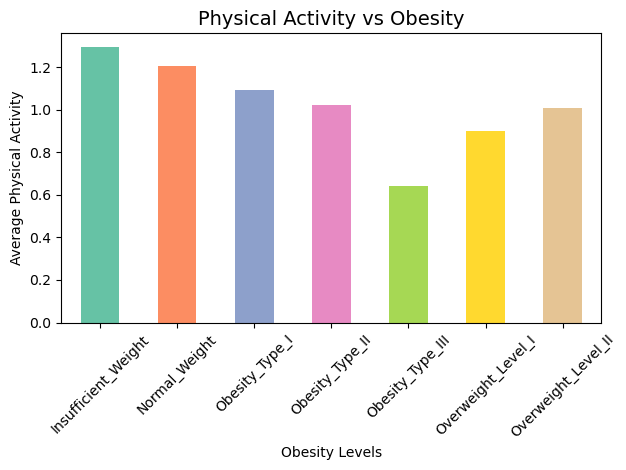

In [8]:
import matplotlib.pyplot as plt

colors = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3',
          '#a6d854','#ffd92f','#e5c494']
df.groupby('NObeyesdad')['FAF'].mean().plot(
    kind='bar',
    color=colors
)
plt.title("Physical Activity vs Obesity", fontsize=14)
plt.xlabel("Obesity Levels")
plt.ylabel("Average Physical Activity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df.groupby('NObeyesdad')['CH2O'].mean()

NObeyesdad
Insufficient_Weight    1.954096
Normal_Weight          1.777540
Obesity_Type_I         2.189669
Obesity_Type_II        1.948412
Obesity_Type_III       2.204639
Overweight_Level_I     1.955004
Overweight_Level_II    2.000131
Name: CH2O, dtype: float64

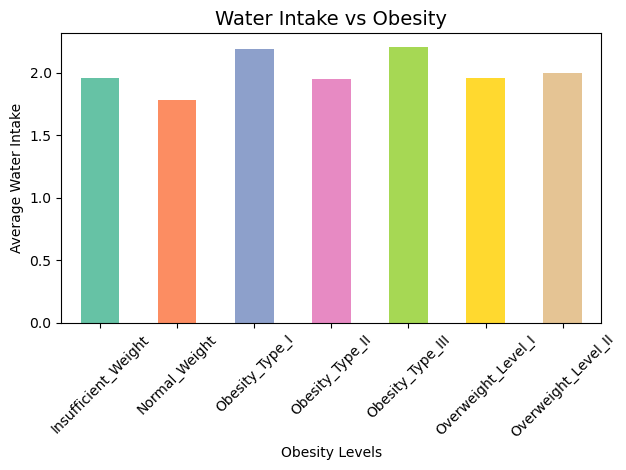

In [10]:
import matplotlib.pyplot as plt

colors = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3',
          '#a6d854','#ffd92f','#e5c494']

df.groupby('NObeyesdad')['CH2O'].mean().plot(
    kind='bar',
    color=colors
)

plt.title("Water Intake vs Obesity", fontsize=14)
plt.xlabel("Obesity Levels")
plt.ylabel("Average Water Intake")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df.groupby('NObeyesdad')['TUE'].mean()

NObeyesdad
Insufficient_Weight    0.808581
Normal_Weight          0.674113
Obesity_Type_I         0.765689
Obesity_Type_II        0.541746
Obesity_Type_III       0.593211
Overweight_Level_I     0.744794
Overweight_Level_II    0.716270
Name: TUE, dtype: float64

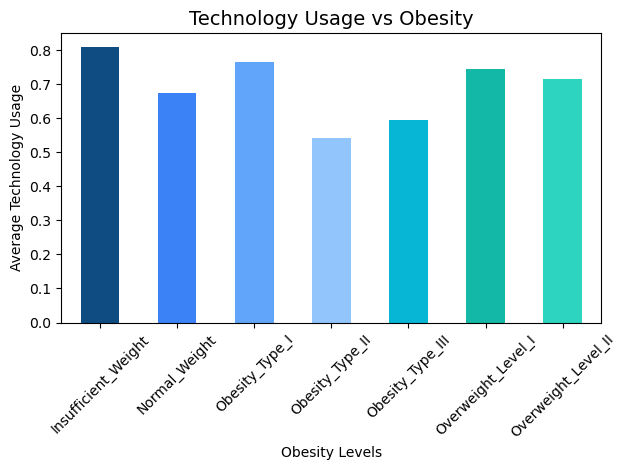

In [12]:
import matplotlib.pyplot as plt
colors = ['#0F4C81','#3B82F6','#60A5FA',
          '#93C5FD','#06B6D4','#14B8A6','#2DD4BF']
df.groupby('NObeyesdad')['TUE'].mean().plot(
    kind='bar',
    color=colors
)
plt.title("Technology Usage vs Obesity", fontsize=14)
plt.xlabel("Obesity Levels")
plt.ylabel("Average Technology Usage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
df['FAVC'].value_counts()

FAVC
yes    606
no      91
Name: count, dtype: int64

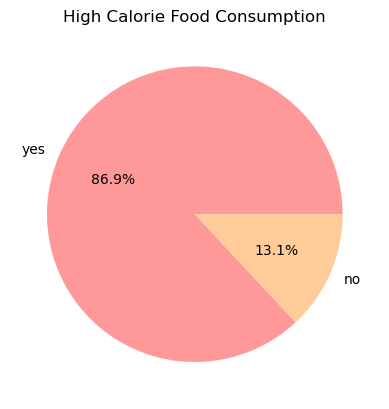

In [14]:
import matplotlib.pyplot as plt
colors = ['#FF9999', '#FFCC99']
df['FAVC'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors
)
plt.title("High Calorie Food Consumption")
plt.ylabel("")
plt.show()

In [15]:
pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'])

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history_with_overweight,,,,,,,
no,46,46,2,0,0,27,6
yes,44,57,112,95,115,64,83


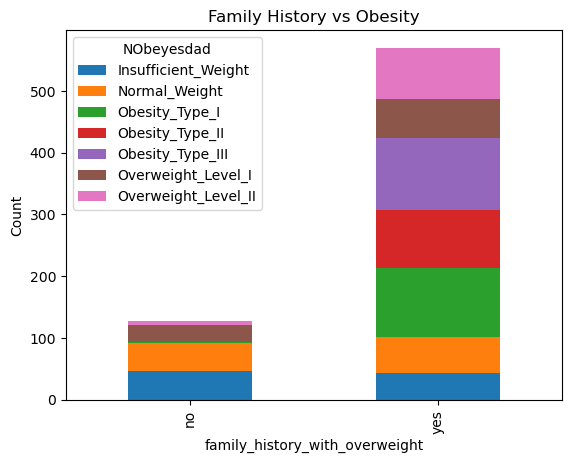

In [16]:
pd.crosstab(df['family_history_with_overweight'],df['NObeyesdad']).plot(kind='bar', stacked=True)
plt.title("Family History vs Obesity")
plt.ylabel("Count")
plt.show()

In [17]:
df['FAF'].describe()

count    697.000000
mean       1.014961
std        0.859048
min        0.000000
25%        0.098043
50%        1.000000
75%        1.679935
max        3.000000
Name: FAF, dtype: float64

In [18]:
df['TUE'].describe()

count    697.000000
mean       0.689676
std        0.595110
min        0.000000
25%        0.069367
50%        0.686720
75%        1.000000
max        2.000000
Name: TUE, dtype: float64

In [19]:
df.describe()

,Age,Weight,Height,CH2O,FAF,TUE
count,697.000000,697.000000,697.000000,697.000000,697.000000,697.000000
mean,23.848546,86.633150,1.700122,2.013095,1.014961,0.689676
std,5.719248,26.576694,0.092595,0.589364,0.859048,0.595110
min,14.000000,39.695295,1.450000,1.000000,0.000000,0.000000
25%,19.885655,65.000000,1.630000,1.678791,0.098043,0.069367
50%,22.740275,83.000000,1.700000,2.000000,1.000000,0.686720
75%,26.000000,108.602715,1.768435,2.451260,1.679935,1.000000
max,55.246250,173.000000,1.930000,3.000000,3.000000,2.000000


In [20]:
print("===== HEALTH INSIGHTS =====")
if df['FAF'].mean() < 1.5:
    print("• Low physical activity is associated with obesity.")
if df['CH2O'].mean() < 2:
    print("• Water intake can be improved.")
else:
    print("• Average water intake is within a healthy range.")
print("• Family history is an important obesity factor.")

===== HEALTH INSIGHTS =====
• Low physical activity is associated with obesity.
• Average water intake is within a healthy range.
• Family history is an important obesity factor.


## Health Personas Derived from Dataset

🟢 Healthy Active Persona

Characteristics:
- High Physical Activity (FAF > 2)
- Good Water Intake (CH2O > 2)
- Low High-Calorie Food Consumption

Likely Outcome:
Normal Weight

🟡 Moderate Risk Persona

Characteristics:
- Moderate Physical Activity
- Average Water Intake
- Occasional High-Calorie Food Consumption

Likely Outcome:
Overweight Risk

🔴 High Risk Persona

Characteristics:
- Low Physical Activity (FAF < 1)
- Family History of Overweight
- Frequent High-Calorie Food Consumption

Likely Outcome:
Obesity Risk

In [21]:
healthy = df[
    (df['FAF'] > 2) &
    (df['CH2O'] > 2)
]
healthy.head()

,Age,Gender,Weight,Height,FAVC,CH2O,FAF,TUE,family_history_with_overweight,NObeyesdad
19,33.081600,Male,83.016968,1.705617,yes,2.991671,2.148738,0.000000,yes,Overweight_Level_II
29,20.242237,Male,54.567343,1.756330,yes,2.654078,2.113151,0.686720,yes,Insufficient_Weight
43,19.000000,Male,79.000000,1.880000,no,3.000000,3.000000,0.000000,no,Normal_Weight
63,18.525525,Male,59.258372,1.856633,yes,2.036764,2.038653,1.119877,yes,Insufficient_Weight
81,23.096353,Male,97.959899,1.728183,yes,2.364208,2.492402,1.632506,yes,Obesity_Type_I


In [22]:
moderate = df[
    (df['FAF'] >= 1) &
    (df['FAF'] <= 2)
]
moderate.head()

,Age,Gender,Weight,Height,FAVC,CH2O,FAF,TUE,family_history_with_overweight,NObeyesdad
2,18.000000,Male,60.000000,1.850000,yes,2.000000,2.000000,0.000000,yes,Insufficient_Weight
4,22.000000,Male,74.000000,1.750000,no,2.000000,1.000000,2.000000,yes,Normal_Weight
11,18.301773,Female,140.292018,1.808765,yes,2.830247,1.783138,0.789064,yes,Obesity_Type_III
12,28.393111,Male,99.540122,1.685462,yes,1.000000,1.621733,0.138314,yes,Obesity_Type_II
13,30.242597,Male,118.382361,1.759772,yes,2.208068,1.076720,1.035711,yes,Obesity_Type_II


In [23]:
high_risk = df[
    (df['FAF'] < 1) &
    (df['family_history_with_overweight'] == 'yes')
]
high_risk.head()

,Age,Gender,Weight,Height,FAVC,CH2O,FAF,TUE,family_history_with_overweight,NObeyesdad
1,26.000000,Female,111.004920,1.624950,yes,2.704315,0.000000,0.322666,yes,Obesity_Type_III
5,18.000000,Male,50.248677,1.738702,yes,1.283738,0.684879,1.487223,yes,Insufficient_Weight
6,26.684354,Male,118.332689,1.819535,yes,2.357969,0.704236,0.010721,yes,Obesity_Type_II
7,30.000000,Female,71.000000,1.650000,yes,1.000000,0.000000,0.000000,yes,Overweight_Level_I
8,23.099906,Female,78.997166,1.571812,yes,2.000000,0.402614,0.000000,yes,Obesity_Type_I


In [24]:
print("Healthy Persona:", len(healthy))
print("Moderate Persona:", len(moderate))
print("High Risk Persona:", len(high_risk))

Healthy Persona: 37
Moderate Persona: 305
High Risk Persona: 277
